In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("diamonds")
print("shape:",df.shape)

shape: (53940, 10)


In [2]:
print("\nColumns:", list(df.columns))
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicated:", df.duplicated().sum())


Columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Data Types:
 carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Missing Values:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Duplicated: 146


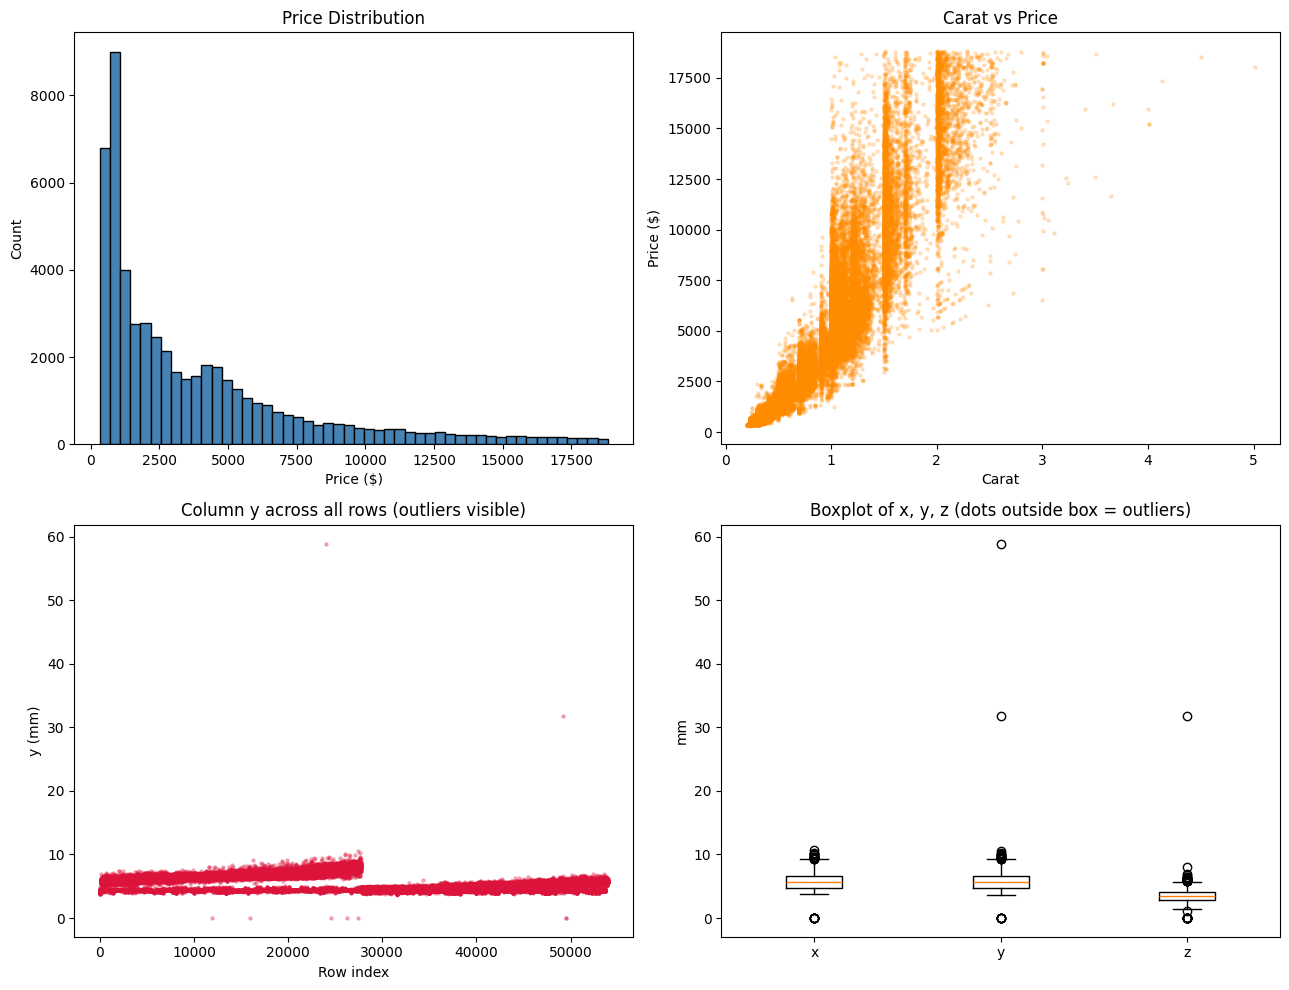

In [ ]:
#حذف العناصر التي تحتوي على قيم الصفر ف احد الأبعاد
df = df[~((df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0))]

In [4]:
#تنظيف القيم التي تكون ابعاد ال y and z مخالفة للشرط المنطقي 
df = df[(df['y']<20) & (df['z']<10)]

In [ ]:
#ازالة التكرار
df = df.drop_duplicates()

In [6]:
print("الحجم بعد التنظيف : ",df.shape)

الحجم بعد التنظيف :  (53791, 10)


In [ ]:
df.to_csv("diamonds_clean.csv",index=False)


تم الحفظ 


In [ ]:
df = pd.read_csv("diamonds_clean.csv")


In [ ]:
# بنعرّف ترتيب كل عمود نصي يدويًا، من الأسوأ للأفضل
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

In [9]:
#pd.Categorical بتحول العمود لنوع خاص "فئوي مرتّب"
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)
df['color'] = pd.Categorical(df['color'], categories=color_order, ordered=True)
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True)


In [10]:
#التحويل من كلمات ال ارقام 
df['cut']=df['cut'].cat.codes
df['color']=df['color'].cat.codes
df['clarity']=df['clarity'].cat.codes

In [11]:
print(df[['cut', 'color', 'clarity']].head())
print("\nأنواع الأعمدة بعد التحويل:")
print(df.dtypes)

   cut  color  clarity
0    4      5        1
1    3      5        2
2    1      5        4
3    3      1        3
4    1      0        1

أنواع الأعمدة بعد التحويل:
carat      float64
cut           int8
color         int8
clarity       int8
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


In [12]:
df.to_csv("diamonds_encoded.csv", index=False)
print("\nتم حفظ diamonds_encoded.csv")


تم حفظ diamonds_encoded.csv


In [13]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("diamonds_encoded.csv")


In [18]:
X = df.drop('price',axis= 1)
y = df['price']
print("X:",X.shape)
print("Y:",y.shape)
print("X columns :",list(X.columns))

X: (53791, 9)
Y: (53791,)
X columns : ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\nحجم بيانات التدريب:", X_train.shape)
print("حجم بيانات الاختبار:", X_test.shape)


حجم بيانات التدريب: (43032, 9)
حجم بيانات الاختبار: (10759, 9)


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

modle = LinearRegression()
modle.fit(X_train,y_train)

LinearRegression()

In [20]:
y_pred=modle.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print(f"MAE  (متوسط الخطأ المطلق): ${mae:,.2f}")
print(f"RMSE (جذر متوسط مربع الخطأ): ${rmse:,.2f}")
print(f"R²   (نسبة التفسير): {r2:.4f}")

MAE  (متوسط الخطأ المطلق): $792.09
RMSE (جذر متوسط مربع الخطأ): $1,181.78
R²   (نسبة التفسير): 0.9075


In [22]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train,y_train)

RandomForestRegressor()

In [23]:
y_pred_rf=rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"MAE  (Random Forest): ${mae_rf:,.2f}")
print(f"RMSE (Random Forest): ${rmse_rf:,.2f}")
print(f"R²   (Random Forest): {r2_rf:.4f}")

MAE  (Random Forest): $263.07
RMSE (Random Forest): $542.24
R²   (Random Forest): 0.9805


In [ ]:
#شو اكثر feature اثر على قرار المودل
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
print("\nأهمية كل عمود بالتنبؤ:")
print(importances.sort_values(ascending=False))


أهمية كل عمود بالتنبؤ:
carat      0.502562
y          0.386483
clarity    0.061360
color      0.032262
x          0.005157
z          0.005025
depth      0.003116
table      0.002241
cut        0.001794
dtype: float64


In [25]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],       # عدد الأشجار
    'max_depth': [10, 20, 30, None],       # أقصى عمق للشجرة (None = بدون حد)
    'min_samples_split': [2, 5, 10],       # أقل عدد عينات لازم عشان تنفرع الشجرة
    'min_samples_leaf': [1, 2, 4],         # أقل عدد عينات لازم يكون بآخر ورقة بالشجرة
    'max_features': ['sqrt', 'log2', None] # كم عمود يجرب بكل تفرّع
}

In [26]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=2   # بيطبعلك تقدم العملية أول بأول (مفيد لأنه العملية بتاخد وقت)
)

In [27]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [28]:
print("أفضل تركيبة إعدادات:")
print(random_search.best_params_)
# best_estimator_ هو الموديل المدرّب بأفضل إعدادات لقيناها
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)
print(f"\nMAE  (بعد التحسين): ${mae_best:,.2f}")
print(f"RMSE (بعد التحسين): ${rmse_best:,.2f}")
print(f"R²   (بعد التحسين): {r2_best:.4f}")

أفضل تركيبة إعدادات:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 30}

MAE  (بعد التحسين): $262.31
RMSE (بعد التحسين): $545.71
R²   (بعد التحسين): 0.9803
